# Deteksi Outlier Konsentrasi 4 Polutan (CH4, CO, NO2, SO2) Menggunakan Metode Interquartile Range (IQR)

**Dataset**: `data/csv/pertemuan-5-csv/Hasil Polutan.csv` (Rentang 1 - 365 Hari Pengamatan: 24 Agustus 2025 s.d. 23 Agustus 2026)  
**Tujuan**: Melakukan identifikasi dan pembersihan data pencilan (*outliers*) pada 4 polutan udara (`CH4`, `CO`, `NO2`, `SO2`) menggunakan metode **Interquartile Range (IQR)** dengan aturan pagar Tukey ($1.5 \times IQR$), menyajikan visualisasi runtun waktu komparatif lengkap dengan zona pagar batas (*fences*), menyusun **tabel urutan data outlier** secara terstruktur di bawah visualisasi (kronologis dan tingkat keparahan deviasi), serta mengekspor dataset bersih terstandarisasi untuk tahapan penambalan nilai kosong (*missing value*).

## Tahap 1: Memuat Data dan Eksplorasi Profil 4 Polutan (Hari 1 - 365)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Pemuatan dataset mentah hasil observasi 4 polutan
input_path = "../data/csv/pertemuan-5-csv/Hasil Polutan.csv"
if not os.path.exists(input_path):
    input_path = "data/csv/pertemuan-5-csv/Hasil Polutan.csv"

df_raw = pd.read_csv(input_path)

# 2. Pembatasan tepat pada rentang 365 hari pengamatan pertama
df = df_raw.iloc[:365].copy()
df['tanggal'] = pd.to_datetime(df['tanggal'])

pollutants = ['CH4', 'CO', 'NO2', 'SO2']

# 3. Profil ketersediaan data 4 polutan
profil_data = []
for p in pollutants:
    n_valid = df[p].notna().sum()
    n_missing = df[p].isna().sum()
    pct_valid = (n_valid / len(df)) * 100
    pct_missing = (n_missing / len(df)) * 100
    profil_data.append({
        'Polutan': p,
        'Total Hari': len(df),
        'Data Valid (Hari)': n_valid,
        'Persentase Valid (%)': f"{pct_valid:.2f}%",
        'Missing Values (Hari)': n_missing,
        'Persentase Missing (%)': f"{pct_missing:.2f}%"
    })

df_profil = pd.DataFrame(profil_data)

print("=== PROFIL DATASET 4 POLUTAN 1 TAHUN (HARI 1 - 365) ===")
print(f"Total Baris Data        : {len(df)} hari")
print(f"Rentang Tanggal         : {df['tanggal'].min().strftime('%Y-%m-%d')} s.d. {df['tanggal'].max().strftime('%Y-%m-%d')}")
display(df_profil)

print("\n--- 5 Baris Pertama Dataset ---")
display(df.head())

=== PROFIL DATASET 4 POLUTAN 1 TAHUN (HARI 1 - 365) ===
Total Baris Data        : 365 hari
Rentang Tanggal         : 2025-08-24 s.d. 2026-08-23


,Polutan,Total Hari,Data Valid (Hari),Persentase Valid (%),Missing Values (Hari),Persentase Missing (%)
0,CH4,365,17,4.66%,348,95.34%
1,CO,365,214,58.63%,151,41.37%
2,NO2,365,188,51.51%,177,48.49%
3,SO2,365,230,63.01%,135,36.99%



--- 5 Baris Pertama Dataset ---


,tanggal,CH4,CO,NO2,SO2
0,2025-08-24,NaN,NaN,0.000029,0.000346
1,2025-08-25,1867.289429,0.029300,0.000040,0.000038
2,2025-08-26,NaN,NaN,0.000040,-0.000758
3,2025-08-27,NaN,0.028946,NaN,-0.000084
4,2025-08-28,NaN,0.025137,0.000032,-0.000198


## Tahap 2: Eksplorasi Statistik Deskriptif dan Visualisasi Distribusi Awal (4 Polutan)

=== TABEL PARAMETER STATISTIK DESKRIPTIF & PAGAR IQR 4 POLUTAN ===


,Polutan,Jumlah Valid,Mean (μ),Std Dev (σ),Median (Q2),Q1 (25%),Q3 (75%),IQR,Batas Bawah (Q1-1.5*IQR),Batas Atas (Q3+1.5*IQR),Min,Max,Skewness,Kurtosis
0,CH4,17,1.888264e+03,2.234374e+01,1.891956e+03,1.881687e+03,1.907414e+03,2.572681e+01,1.843097e+03,1.946004e+03,1.847265e+03,1.915410e+03,-0.7408,-0.5680
1,CO,214,2.877197e-02,3.386706e-03,2.860164e-02,2.655788e-02,3.082733e-02,4.269442e-03,2.015372e-02,3.723149e-02,2.023532e-02,4.648314e-02,+0.6821,+2.8552
2,NO2,188,3.024087e-05,1.819139e-05,2.890000e-05,1.910000e-05,3.902500e-05,1.992500e-05,-1.078750e-05,6.891250e-05,-9.630000e-06,9.860000e-05,+0.9601,+2.1007
3,SO2,230,3.196495e-05,2.364778e-04,3.230000e-05,-9.290000e-05,1.441252e-04,2.370253e-04,-4.484379e-04,4.996631e-04,-7.582780e-04,8.376940e-04,+0.0509,+1.4469


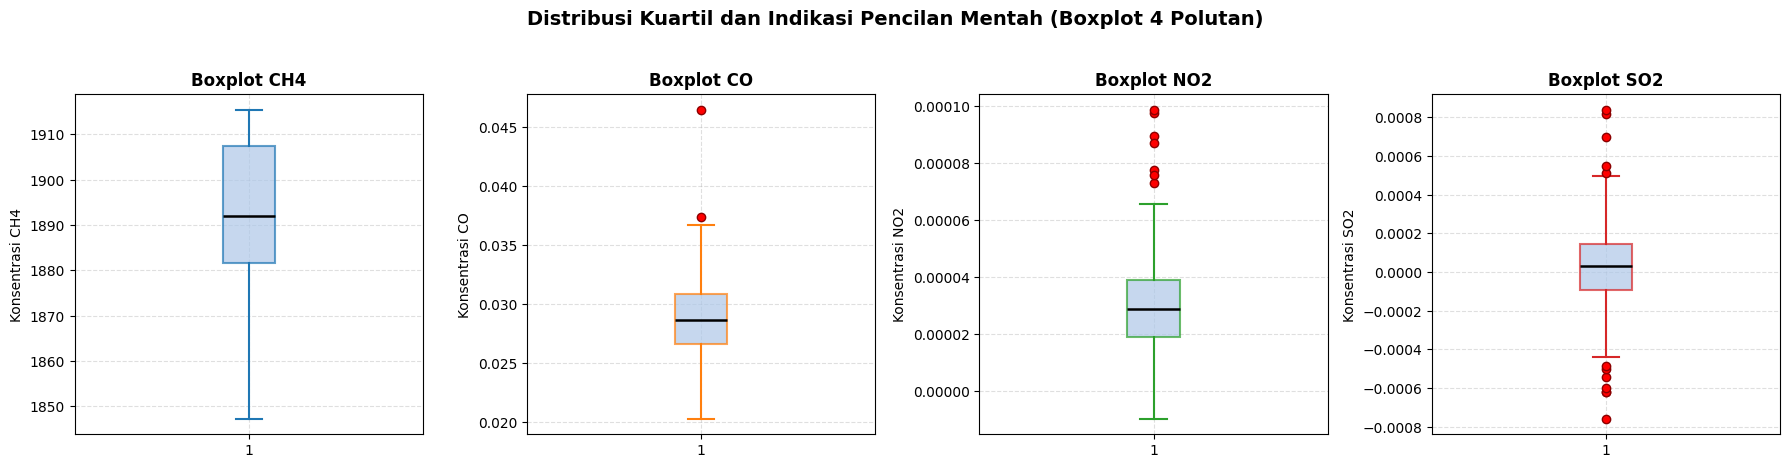

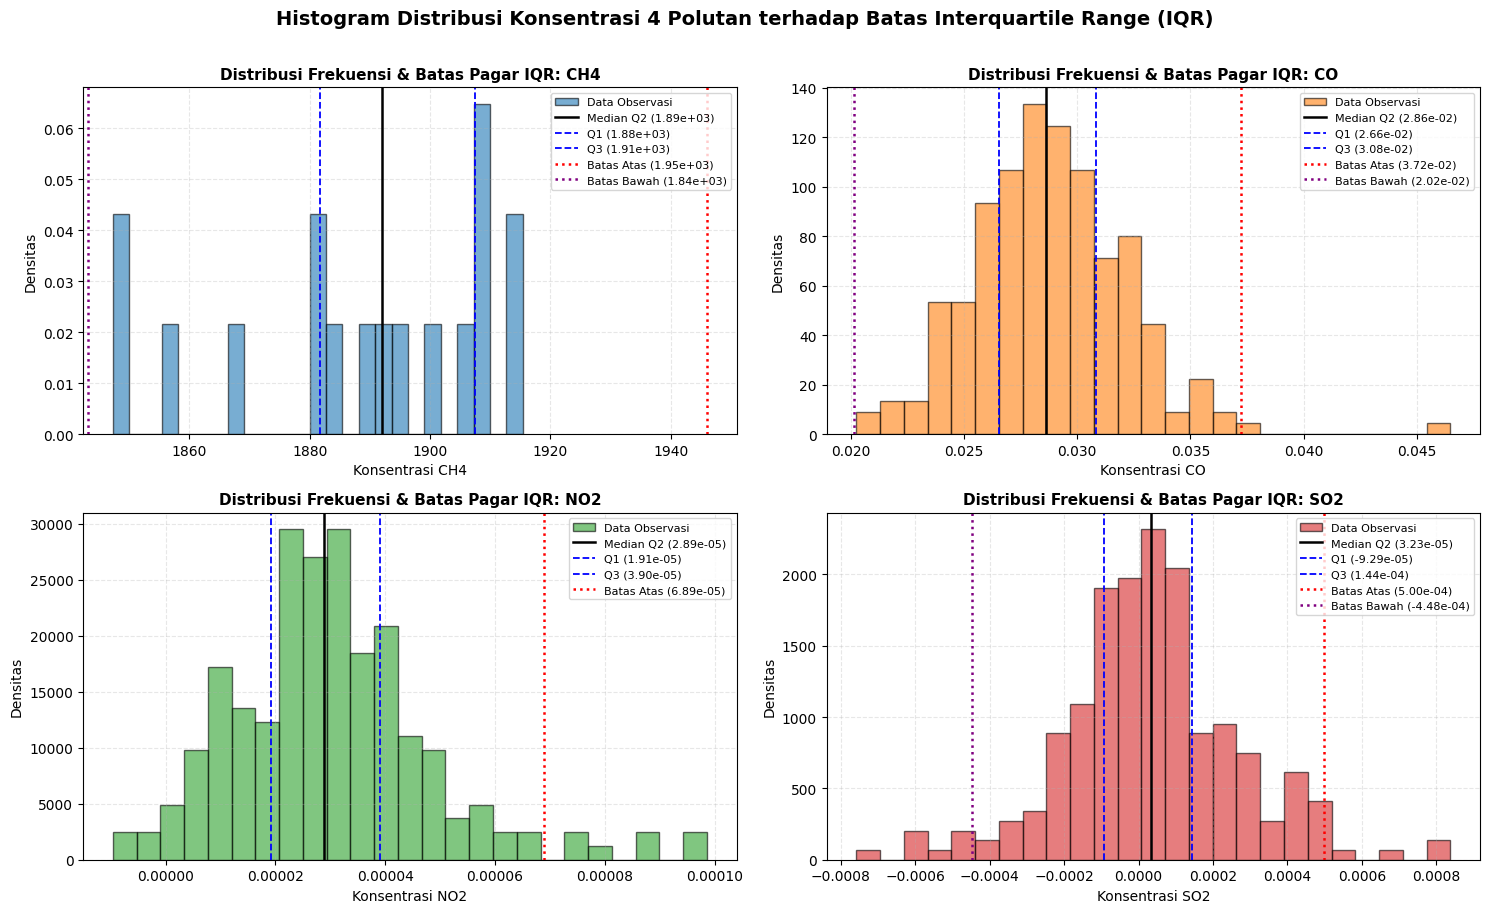

In [2]:
# 1. Komputasi Parameter Statistik Deskriptif & Kuartil 4 Polutan
stats_summary = []
for p in pollutants:
    s = df[p].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    stats_summary.append({
        'Polutan': p,
        'Jumlah Valid': len(s),
        'Mean (μ)': f"{s.mean():.6e}",
        'Std Dev (σ)': f"{s.std():.6e}",
        'Median (Q2)': f"{s.median():.6e}",
        'Q1 (25%)': f"{q1:.6e}",
        'Q3 (75%)': f"{q3:.6e}",
        'IQR': f"{iqr:.6e daylight}" if False else f"{iqr:.6e}",
        'Batas Bawah (Q1-1.5*IQR)': f"{lower_fence:.6e}",
        'Batas Atas (Q3+1.5*IQR)': f"{upper_fence:.6e}",
        'Min': f"{s.min():.6e}",
        'Max': f"{s.max():.6e}",
        'Skewness': f"{s.skew():+.4f}",
        'Kurtosis': f"{s.kurtosis():+.4f}"
    })

df_stat_all = pd.DataFrame(stats_summary)
print("=== TABEL PARAMETER STATISTIK DESKRIPTIF & PAGAR IQR 4 POLUTAN ===")
display(df_stat_all)

# 2. Visualisasi Boxplot Distribusi 4 Polutan (Tukey's Fences)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, p in enumerate(pollutants):
    s = df[p].dropna()
    bp = axes[i].boxplot(s, patch_artist=True,
                         boxprops=dict(facecolor='#aec7e8', color=box_colors[i], linewidth=1.5, alpha=0.7),
                         whiskerprops=dict(color=box_colors[i], linewidth=1.5),
                         capprops=dict(color=box_colors[i], linewidth=1.5),
                         medianprops=dict(color='black', linewidth=1.8),
                         flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='darkred', markersize=6))
    axes[i].set_title(f'Boxplot {p}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(f'Konsentrasi {p}', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribusi Kuartil dan Indikasi Pencilan Mentah (Boxplot 4 Polutan)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# 3. Visualisasi Histogram Frekuensi dan Penanda Pagar IQR
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for i, p in enumerate(pollutants):
    s = df[p].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    median_val = s.median()
    
    axes[i].hist(s, bins=25, density=True, alpha=0.6, color=box_colors[i], edgecolor='black', label='Data Observasi')
    axes[i].axvline(median_val, color='black', linestyle='-', linewidth=1.8, label=f'Median Q2 ({median_val:.2e})')
    axes[i].axvline(q1, color='blue', linestyle='--', linewidth=1.3, label=f'Q1 ({q1:.2e})')
    axes[i].axvline(q3, color='blue', linestyle='--', linewidth=1.3, label=f'Q3 ({q3:.2e})')
    axes[i].axvline(ub, color='red', linestyle=':', linewidth=1.8, label=f'Batas Atas ({ub:.2e})')
    if lb >= (s.min() - 0.1 * abs(s.min())):
        axes[i].axvline(lb, color='purple', linestyle=':', linewidth=1.8, label=f'Batas Bawah ({lb:.2e})')
        
    axes[i].set_title(f'Distribusi Frekuensi & Batas Pagar IQR: {p}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'Konsentrasi {p}', fontsize=10)
    axes[i].set_ylabel('Densitas', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.3)
    axes[i].legend(fontsize=8, loc='upper right')

plt.suptitle('Histogram Distribusi Konsentrasi 4 Polutan terhadap Batas Interquartile Range (IQR)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Tahap 3: Deteksi Outlier Menggunakan Metode Interquartile Range (IQR / Tukey's Fences)

Pada tahapan ini, diterapkan algoritma **Interquartile Range (IQR)** dengan aturan pagar Tukey (*Tukey's Fences*) dengan faktor pengali $1.5$:

$$\text{Batas Bawah (Lower Fence)} = Q_1 - 1.5 \times IQR$$
$$\text{Batas Atas (Upper Fence)} = Q_3 + 1.5 \times IQR$$

Di mana:
- $Q_1$ adalah Kuartil Bawah (Persentil ke-25).
- $Q_3$ adalah Kuartil Atas (Persentil ke-75).
- $IQR = Q_3 - Q_1$ adalah Rentang Antarkuartil yang memuat 50% data di area tengah.

### Kriteria Klasifikasi Outlier IQR:
- **Pencilan Atas (Nilai Tinggi)**: Data dengan nilai observasi $x_i > Q_3 + 1.5 \times IQR$
- **Pencilan Bawah (Nilai Rendah)**: Data dengan nilai observasi $x_i < Q_1 - 1.5 \times IQR$

In [3]:
# DETEKSI OUTLIER METODE IQR (1.5 * IQR) UNTUK 4 POLUTAN
all_outliers_records = []
iqr_params = {}

print("=" * 85)
print("MEMULAI PROSES DETEKSI OUTLIER METODE INTERQUARTILE RANGE (IQR) UNTUK 4 POLUTAN")
print("Aturan Pagar Tukey: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]")
print("=" * 85)

for pol in pollutants:
    valid_series = df[pol].dropna()
    q1 = valid_series.quantile(0.25)
    q3 = valid_series.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    
    iqr_params[pol] = {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower_Fence': lower_fence, 'Upper_Fence': upper_fence
    }
    
    outliers = valid_series[(valid_series < lower_fence) | (valid_series > upper_fence)]
    pol_records = []
    
    print(f"\n>>> POLUTAN: {pol} <<<")
    print(f"  Jumlah Data Valid    : {len(valid_series)} hari")
    print(f"  Q1 (25%)             : {q1:.8e}")
    print(f"  Q3 (75%)             : {q3:.8e}")
    print(f"  IQR (Q3 - Q1)        : {iqr:.8e}")
    print(f"  Batas Bawah Pagar    : {lower_fence:.8e}")
    print(f"  Batas Atas Pagar     : {upper_fence:.8e}")
    print(f"  Outlier Ditemukan    : {len(outliers)} titik")
    
    for idx in outliers.index:
        tgl = df.loc[idx, 'tanggal'].strftime('%Y-%m-%d')
        val = df.loc[idx, pol]
        
        if val > upper_fence:
            kategori = 'Pencilan Atas (Tinggi)'
            deviasi_iqr = (val - q3) / iqr
            selisih_batas = val - upper_fence
        else:
            kategori = 'Pencilan Bawah (Rendah)'
            deviasi_iqr = (q1 - val) / iqr
            selisih_batas = lower_fence - val
            
        record = {
            'Polutan': pol,
            'Metode': 'IQR (1.5x)',
            'Index': idx,
            'Hari_Ke': idx + 1,
            'Tanggal': tgl,
            'Nilai': val,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'Batas_Bawah': lower_fence,
            'Batas_Atas': upper_fence,
            'Deviasi_IQR': deviasi_iqr,
            'Selisih_Batas': selisih_batas,
            'Kategori': kategori
        }
        pol_records.append(record)
        all_outliers_records.append(record)
        print(f"    * [Hari ke-{idx+1:3d} | {tgl}] Nilai = {val:.6e} | Deviasi = {deviasi_iqr:.2f}×IQR | Selisih = {selisih_batas:+.3e} ({kategori})")

print("\n" + "=" * 85)
print(f"TOTAL SELURUH OUTLIER TERDETEKSI DARI 4 POLUTAN DENGAN METODE IQR: {len(all_outliers_records)} TITIK")
print("=" * 85)
for p in pollutants:
    sub_count = len([r for r in all_outliers_records if r['Polutan'] == p])
    print(f"- {p:5}: {sub_count:2d} outlier")

MEMULAI PROSES DETEKSI OUTLIER METODE INTERQUARTILE RANGE (IQR) UNTUK 4 POLUTAN
Aturan Pagar Tukey: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

>>> POLUTAN: CH4 <<<
  Jumlah Data Valid    : 17 hari
  Q1 (25%)             : 1.88168738e+03
  Q3 (75%)             : 1.90741419e+03
  IQR (Q3 - Q1)        : 2.57268070e+01
  Batas Bawah Pagar    : 1.84309717e+03
  Batas Atas Pagar     : 1.94600440e+03
  Outlier Ditemukan    : 0 titik

>>> POLUTAN: CO <<<
  Jumlah Data Valid    : 214 hari
  Q1 (25%)             : 2.65578847e-02
  Q3 (75%)             : 3.08273267e-02
  IQR (Q3 - Q1)        : 4.26944200e-03
  Batas Bawah Pagar    : 2.01537218e-02
  Batas Atas Pagar     : 3.72314897e-02
  Outlier Ditemukan    : 2 titik
    * [Hari ke- 45 | 2025-10-07] Nilai = 4.648314e-02 | Deviasi = 3.67×IQR | Selisih = +9.252e-03 (Pencilan Atas (Tinggi))
    * [Hari ke- 48 | 2025-10-10] Nilai = 3.736736e-02 | Deviasi = 1.53×IQR | Selisih = +1.359e-04 (Pencilan Atas (Tinggi))

>>> POLUTAN: NO2 <<<
  Jumlah Data Valid    : 18

## Tahap 4: Visualisasi Hasil Deteksi Outlier IQR & Tabel Urutan Data Outlier

Berikut adalah visualisasi deret waktu komparatif 4 polutan udara dengan zona pagar aman (*safe area band* $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$), garis batas pagar atas/bawah, titik anomali ('X'), serta **3 tabel urutan data outlier secara lengkap dan terstruktur tepat di bawah visualisasi**.

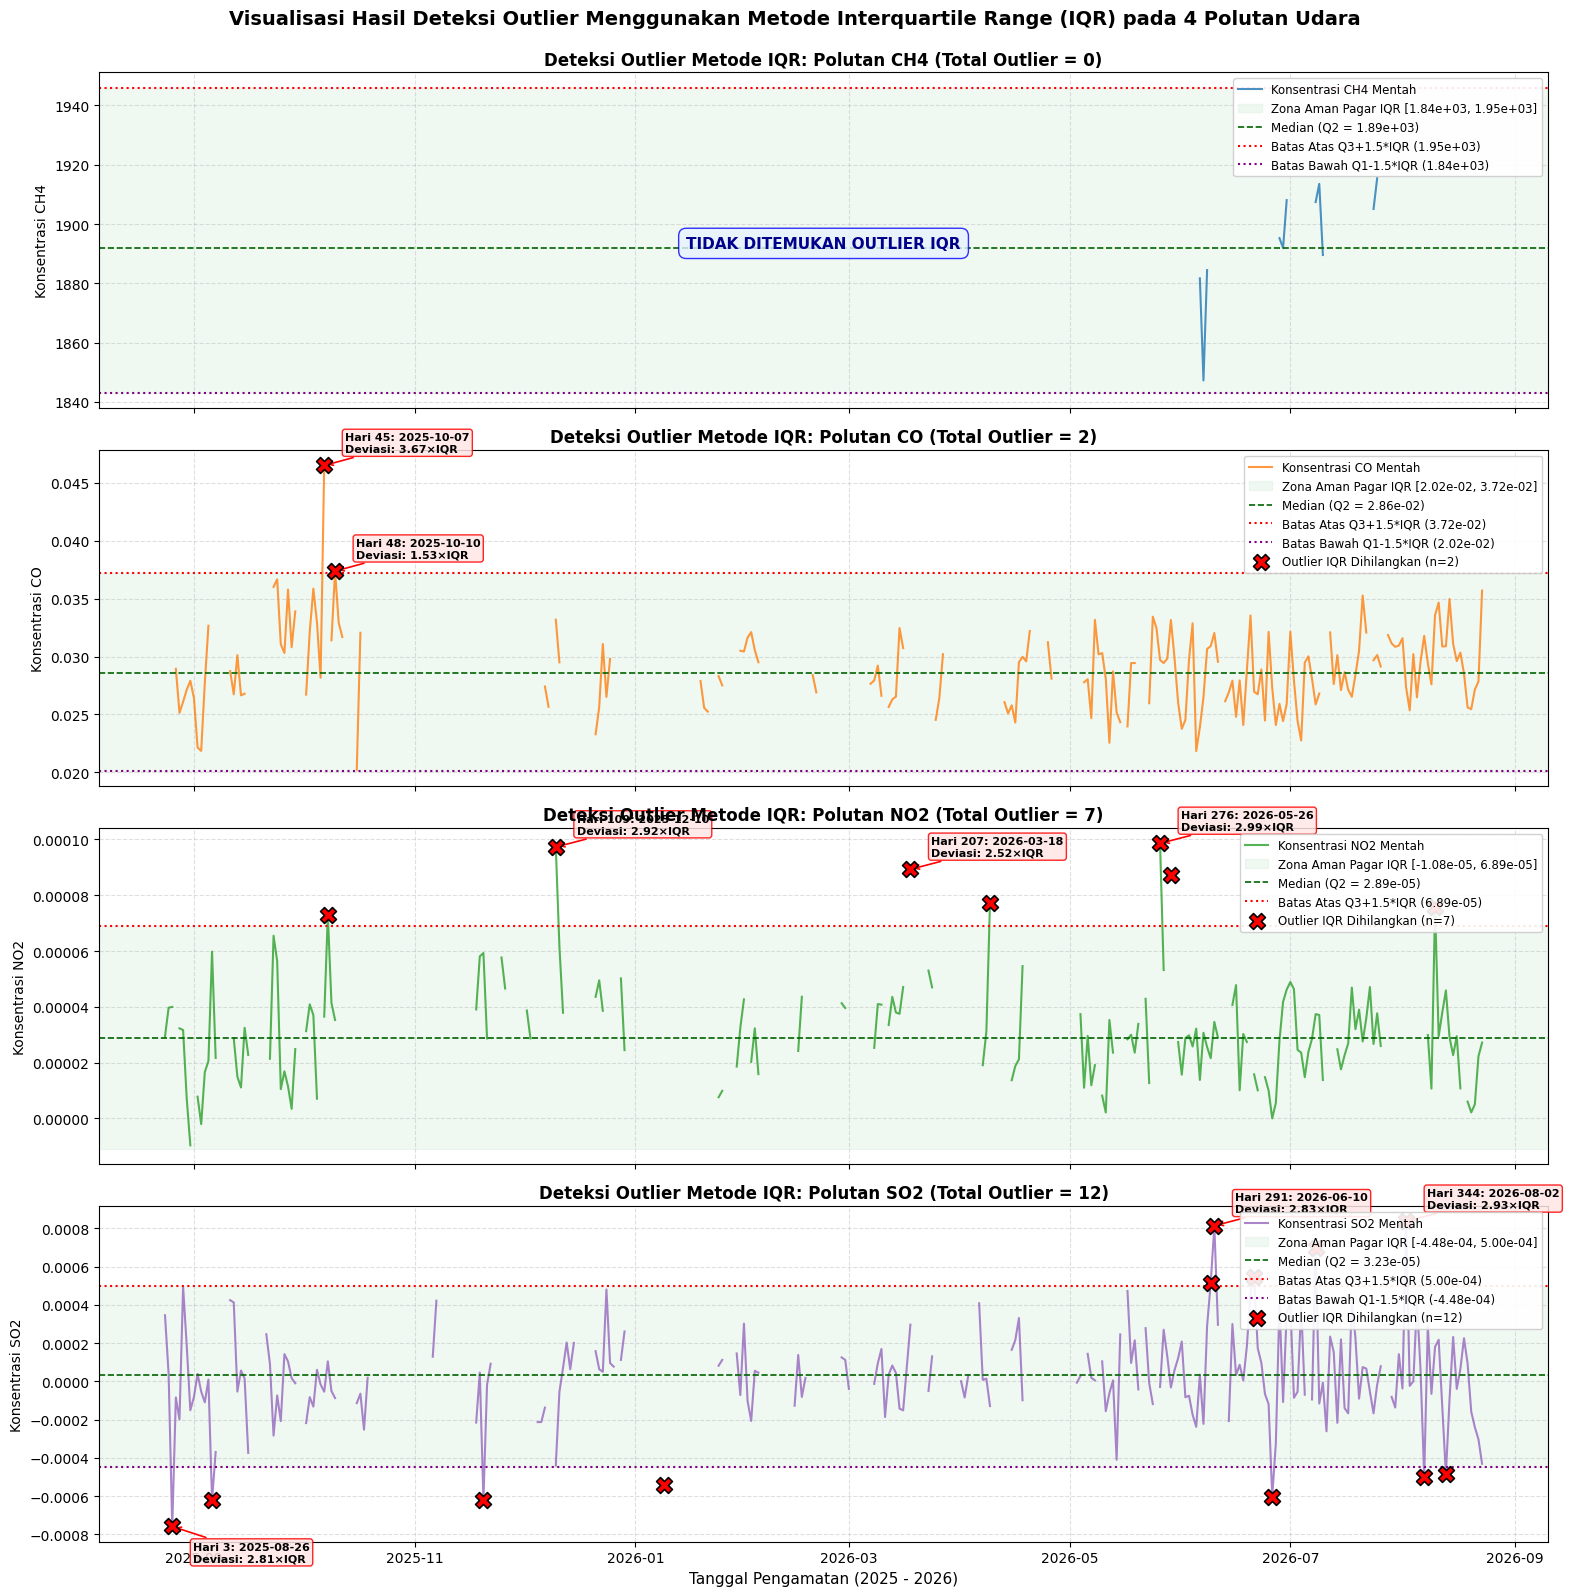

In [4]:
# 1. VISUALISASI HASIL DETEKSI OUTLIER METODE IQR
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
colors_dict = {'CH4': '#1f77b4', 'CO': '#ff7f0e', 'NO2': '#2ca02c', 'SO2': '#9467bd'}

for i, pol in enumerate(pollutants):
    ax = axes[i]
    pol_outliers = [r for r in all_outliers_records if r['Polutan'] == pol]
    outlier_indices = [r['Index'] for r in pol_outliers]
    
    p_info = iqr_params[pol]
    q1 = p_info['Q1']
    q3 = p_info['Q3']
    lb = p_info['Lower_Fence']
    ub = p_info['Upper_Fence']
    median_val = df[pol].dropna().median()
    
    # 1. Garis deret waktu mentah
    ax.plot(df['tanggal'], df[pol], color=colors_dict[pol], linewidth=1.5, alpha=0.8, label=f'Konsentrasi {pol} Mentah')
    
    # 2. Daerah aman batas IQR (Shaded Band)
    ax.axhspan(lb, ub, color='#d4edda', alpha=0.35, label=f'Zona Aman Pagar IQR [{lb:.2e}, {ub:.2e}]')
    
    # 3. Garis batas statistik kuartil & pagar
    ax.axhline(median_val, color='darkgreen', linestyle='--', linewidth=1.2, label=f'Median (Q2 = {median_val:.2e})')
    ax.axhline(ub, color='red', linestyle=':', linewidth=1.5, label=f'Batas Atas Q3+1.5*IQR ({ub:.2e})')
    if lb >= (df[pol].dropna().min() - 0.1 * abs(df[pol].dropna().min())):
        ax.axhline(lb, color='purple', linestyle=':', linewidth=1.5, label=f'Batas Bawah Q1-1.5*IQR ({lb:.2e})')
        
    # 4. Scatter plot titik outlier
    if len(outlier_indices) > 0:
        df_out = df.loc[outlier_indices]
        ax.scatter(df_out['tanggal'], df_out[pol], color='red', marker='X', s=130, edgecolor='black', linewidth=1.2, zorder=5,
                   label=f'Outlier IQR Dihilangkan (n={len(outlier_indices)})')
        
        # Anotasi untuk outlier paling signifikan (deviasi IQR tertinggi)
        top_pol_outliers = sorted(pol_outliers, key=lambda x: x['Deviasi_IQR'], reverse=True)[:3]
        for item in top_pol_outliers:
            ax.annotate(f"Hari {item['Hari_Ke']}: {item['Tanggal']}\nDeviasi: {item['Deviasi_IQR']:.2f}×IQR",
                        xy=(pd.to_datetime(item['Tanggal']), item['Nilai']),
                        xytext=(15, 10 if 'Atas' in item['Kategori'] else -25), textcoords='offset points',
                        fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='#ffe6e6', edgecolor='red', alpha=0.85),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
    else:
        ax.text(df['tanggal'].iloc[len(df)//2], median_val, 'TIDAK DITEMUKAN OUTLIER IQR',
                color='darkblue', fontsize=11, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#e6f2ff', edgecolor='blue', alpha=0.8))
        
    ax.set_title(f'Deteksi Outlier Metode IQR: Polutan {pol} (Total Outlier = {len(outlier_indices)})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Konsentrasi {pol}', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', framealpha=0.9, fontsize=8.5)

axes[-1].set_xlabel('Tanggal Pengamatan (2025 - 2026)', fontsize=11)
plt.suptitle('Visualisasi Hasil Deteksi Outlier Menggunakan Metode Interquartile Range (IQR) pada 4 Polutan Udara', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [5]:
# 2. TABEL URUTAN DATA OUTLIER METODE IQR

df_outliers_all = pd.DataFrame(all_outliers_records)

# Format tabel kronologis outlier
df_display_chrono = df_outliers_all.sort_values(by=['Index', 'Polutan']).copy().reset_index(drop=True)
df_display_chrono['No'] = df_display_chrono.index + 1
df_display_chrono['Nilai Polutan'] = df_display_chrono['Nilai'].apply(lambda x: f"{x:.6e}")
df_display_chrono['Batas Pagar'] = df_display_chrono.apply(
    lambda r: f"> {r['Batas_Atas']:.6e}" if r['Kategori'] == 'Pencilan Atas (Tinggi)' else f"< {r['Batas_Bawah']:.6e}",
    axis=1
)
df_display_chrono['Deviasi IQR'] = df_display_chrono['Deviasi_IQR'].apply(lambda x: f"{x:.2f}x IQR")
df_display_chrono['Hari ke-'] = df_display_chrono['Hari_Ke']

cols_show = ['No', 'Polutan', 'Hari ke-', 'Tanggal', 'Nilai Polutan', 'Batas Pagar', 'Deviasi IQR', 'Kategori']

print("=" * 105)
print(f"DAFTAR LENGKAP SELURUH OUTLIER TERDETEKSI (METODE IQR): TOTAL {len(df_display_chrono)} TITIK DATA")
print("=" * 105)
display(df_display_chrono[cols_show])

# Rekapitulasi per polutan
rekap_data = []
for p in pollutants:
    sub = df_outliers_all[df_outliers_all['Polutan'] == p]
    n_valid = df[p].notna().sum()
    n_out = len(sub)
    pct_out = (n_out / n_valid * 100) if n_valid > 0 else 0
    p_info = iqr_params[p]
    
    rekap_data.append({
        'Polutan': p,
        'Total Data Valid': n_valid,
        'Outlier Ditemukan': n_out,
        'Persentase Outlier': f"{pct_out:.2f}%",
        'Data Bersih': n_valid - n_out,
        'Batas Bawah': f"{p_info['Lower_Fence']:.6e}",
        'Batas Atas': f"{p_info['Upper_Fence']:.6e}"
    })

df_rekap = pd.DataFrame(rekap_data)
print("\n" + "=" * 105)
print("RINGKASAN HASIL DETEKSI OUTLIER METODE IQR PER POLUTAN")
print("=" * 105)
display(df_rekap)

DAFTAR LENGKAP SELURUH OUTLIER TERDETEKSI (METODE IQR): TOTAL 21 TITIK DATA


,No,Polutan,Hari ke-,Tanggal,Nilai Polutan,Batas Pagar,Deviasi IQR,Kategori
0,1,SO2,3,2025-08-26,-7.582780e-04,< -4.484379e-04,2.81x IQR,Pencilan Bawah (Rendah)
1,2,SO2,14,2025-09-06,-6.216250e-04,< -4.484379e-04,2.23x IQR,Pencilan Bawah (Rendah)
2,3,CO,45,2025-10-07,4.648314e-02,> 3.723149e-02,3.67x IQR,Pencilan Atas (Tinggi)
3,4,NO2,46,2025-10-08,7.300000e-05,> 6.891250e-05,1.71x IQR,Pencilan Atas (Tinggi)
4,5,CO,48,2025-10-10,3.736736e-02,> 3.723149e-02,1.53x IQR,Pencilan Atas (Tinggi)
5,6,SO2,89,2025-11-20,-6.211190e-04,< -4.484379e-04,2.23x IQR,Pencilan Bawah (Rendah)
6,7,NO2,109,2025-12-10,9.730000e-05,> 6.891250e-05,2.92x IQR,Pencilan Atas (Tinggi)
7,8,SO2,139,2026-01-09,-5.413860e-04,< -4.484379e-04,1.89x IQR,Pencilan Bawah (Rendah)
8,9,NO2,207,2026-03-18,8.930000e-05,> 6.891250e-05,2.52x IQR,Pencilan Atas (Tinggi)
9,10,NO2,229,2026-04-09,7.740000e-05,> 6.891250e-05,1.93x IQR,Pencilan Atas (Tinggi)



RINGKASAN HASIL DETEKSI OUTLIER METODE IQR PER POLUTAN


,Polutan,Total Data Valid,Outlier Ditemukan,Persentase Outlier,Data Bersih,Batas Bawah,Batas Atas
0,CH4,17,0,0.00%,17,1.843097e+03,1.946004e+03
1,CO,214,2,0.93%,212,2.015372e-02,3.723149e-02
2,NO2,188,7,3.72%,181,-1.078750e-05,6.891250e-05
3,SO2,230,12,5.22%,218,-4.484379e-04,4.996631e-04


## Tahap 5: Penghilangan Outlier, Ekspor Data Bersih, dan Uji Verifikasi Kebersihan

Pada tahap akhir ini:
1. Seluruh titik data pencilan (*outliers*) pada ke-4 polutan digantikan dengan `NaN` pada struktur deret waktu 365 hari lengkap (disimpan sebagai `polutan_4_clean_iqr.csv` di folder `clean outlier`). Hal ini menjaga kontinuitas waktu untuk tahapan penambalan (*missing value imputation*).
2. Daftar rincian data outlier diekspor ke file `daftar_outlier_iqr.csv`.
3. Dilakukan uji verifikasi IQR ulang terhadap batas pagar untuk memastikan data bersih **100% bebas dari pencilan**.

In [6]:
# 1. Dataset Bersih: Outlier diubah menjadi NaN (mempertahankan struktur 365 hari lengkap)
df_clean = df.copy()

for r in all_outliers_records:
    pol = r['Polutan']
    idx = r['Index']
    df_clean.loc[idx, pol] = np.nan

# 2. Output folder di data/csv/pertemuan-5-csv/clean outlier
output_folder = "../data/csv/pertemuan-5-csv/clean outlier"
if not os.path.exists(output_folder) and not os.path.exists("../data/csv/pertemuan-5-csv"):
    output_folder = "data/csv/pertemuan-5-csv/clean outlier"
os.makedirs(output_folder, exist_ok=True)

# Ekspor Dataset Bersih Utama IQR
clean_csv_path = os.path.join(output_folder, "polutan_4_clean_iqr.csv")
df_clean.to_csv(clean_csv_path, index=False)
# Simpan salinan polutan_4_clean.csv untuk kompatibilitas
df_clean.to_csv(os.path.join(output_folder, "polutan_4_clean.csv"), index=False)
print(f"✓ 1. File dataset bersih (outlier -> NaN) berhasil disimpan di:\n     {clean_csv_path}")

# Ekspor Daftar Outlier IQR Sederhana
outlier_csv_path = os.path.join(output_folder, "daftar_outlier_iqr.csv")
df_display_chrono[cols_show].to_csv(outlier_csv_path, index=False)
print(f"✓ 2. File daftar outlier ({len(df_display_chrono)} baris) berhasil disimpan di:\n     {outlier_csv_path}")

# 3. Uji Verifikasi IQR Ulang pada Dataset Bersih
print("\n" + "=" * 85)
print("UJI VERIFIKASI KEBERSIHAN DATASET PADA BATAS PAGAR IQR")
print("=" * 85)

verif_rows = []
for p in pollutants:
    s_clean = df_clean[p].dropna()
    lb = iqr_params[p]['Lower_Fence']
    ub = iqr_params[p]['Upper_Fence']
    sisa_outlier = ((s_clean < lb) | (s_clean > ub)).sum()
    
    verif_rows.append({
        'Polutan': p,
        'Total Baris': len(df_clean),
        'Data Valid Bersih': len(s_clean),
        'Missing Values (NaN)': df_clean[p].isna().sum(),
        'Outlier Sisa': sisa_outlier,
        'Status': '100% BEBAS OUTLIER ✓' if sisa_outlier == 0 else 'ADA SISA OUTLIER ✗'
    })

df_verif = pd.DataFrame(verif_rows)
display(df_verif)

✓ 1. File dataset bersih (outlier -> NaN) berhasil disimpan di:
     ../data/csv/pertemuan-5-csv/clean outlier\polutan_4_clean_iqr.csv
✓ 2. File daftar outlier (21 baris) berhasil disimpan di:
     ../data/csv/pertemuan-5-csv/clean outlier\daftar_outlier_iqr.csv

UJI VERIFIKASI KEBERSIHAN DATASET PADA BATAS PAGAR IQR


,Polutan,Total Baris,Data Valid Bersih,Missing Values (NaN),Outlier Sisa,Status
0,CH4,365,17,348,0,100% BEBAS OUTLIER ✓
1,CO,365,212,153,0,100% BEBAS OUTLIER ✓
2,NO2,365,181,184,0,100% BEBAS OUTLIER ✓
3,SO2,365,218,147,0,100% BEBAS OUTLIER ✓
